# Road Accident Severity Prediction India 

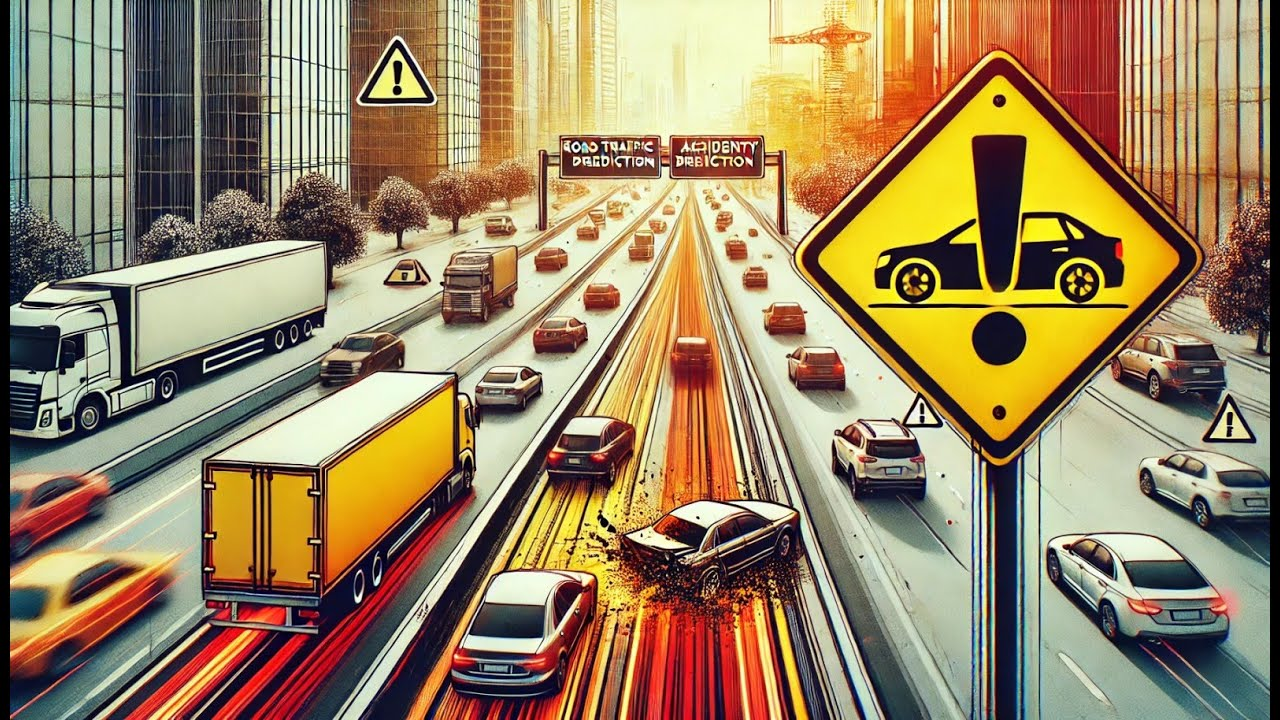

# Project Objective: 

This project analyzes road accident data in India to predict accident severity—slight, serious, or fatal—using features such as driver demographics, vehicle type, road conditions, and environmental factors. Accurate prediction can help authorities identify high-risk scenarios, improve road safety measures, and reduce casualties across the country

# Step-1: Import important libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error
import warnings
warnings.filterwarnings('ignore')
print('All modules Loaded Successfully')

# Step-2: Load Data / Create DF 

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("s3programmer/road-accident-severity-in-india")

print("Path to dataset files:", path)

In [ ]:
os.listdir(path)

In [ ]:
file_path = path + '/' + os.listdir(path)[0]
df = pd.read_csv(file_path)
print('Done')

In [ ]:
df

# Step-3: EDA

In [ ]:
df.head()

In [ ]:
df.tail()

In [ ]:
r,c = df.shape
print(f'''Dataset Contains:
Rows: {r}
Coloumns: {c}''')

In [ ]:
df.info()

In [ ]:
df.isna().sum().sort_values(ascending=False)

In [ ]:
sns.heatmap(df.isnull())

In [ ]:
df['Defect_of_vehicle'].unique()

#### Here :
- 5 - Headlight / Lighting Defect
- 7 - Other mechanical Failures

In [ ]:
nan_cols = df.columns[df.isna().any()]   # select only columns with NaN

for col in nan_cols:
    print(f"Column: {col}")
    print(df[col].unique())   # shows unique values including NaN
    print("-" * 40)

#### Starting to treat Nan Values of Defect_of_vehicle

In [ ]:
df['Defect_of_vehicle'].value_counts()

**Defect of Vehicle Codes:**

- 1 → No defect
- 2 → Brake failure
- 3 → Tyre burst
- 4 → Steering failure
- 5 → Headlight / lighting defect (poor visibility due to faulty lights)
- 6 → Overloading / load-related defect
- 7 → Other mechanical defect
- 9 → Not known

In [ ]:
df['Defect_of_vehicle'].fillna(9, inplace=True)
print('Done')
# filling the Nan Values with the number 9

# #Service_year_of_vehicle, Driving_experience: has it's values in ranges, have to solve later 

In [ ]:
df.isna().sum().sort_values(ascending=False)

In [ ]:
df['Defect_of_vehicle'].unique()

In [ ]:
df['Defect_of_vehicle'].replace({"No defect": 1}, inplace=True)
print('Nan values of Defect_of_vehicle are treated..!!!')
# Here we have replaced the row-value: No Defects with 1

In [ ]:
df['Defect_of_vehicle'].unique()

In [ ]:
df['Work_of_casuality'].fillna('Unknown', inplace=True)
print('Nan values of Work_of_casuality are treated..!!')
# filling the Nan Values with the Unknown

In [ ]:
df['Work_of_casuality'].unique()

In [ ]:
df.isna().sum().sort_values(ascending=False)

In [ ]:
df['Fitness_of_casuality'].fillna('Unknown', inplace=True)
print('Nan values of Fitness_of_casuality are treated..!!')
# Replacing Nan values of Fitness_of_casuality with Unknown

In [ ]:
df.isna().sum().sort_values(ascending=False)

In [ ]:
df['Types_of_Junction'].fillna('Unknown', inplace = True)
df['Educational_level'].fillna('Unknown', inplace = True)
df['Vehicle_driver_relation'].fillna('Unkown', inplace = True)
df['Road_allignment'].fillna('Unknown',inplace = True)
df['Road_surface_type'].fillna('Unknown',inplace = True)
df['Type_of_collision'].fillna('Unknown',inplace = True)


print('''Nan Values of the following are treated successfully..!!! : 
1. Types_of_Junction
2. Vehicle_driver_relation 
3. Educational_level
4. Road_allignment
5. Road_surface_type
6. Type_of_collision''')

In [ ]:
df.isna().sum().sort_values(ascending=False)

In [ ]:
# Counting the number of times 'Unknown is coming in a column'

for col in df.columns:
    count = (df[col] == "Unknown").sum()
    if count > 0:
        print(f"{col}: {count}")


In [ ]:
df['Type_of_vehicle'].fillna('Unkown', inplace = True)
df['Service_year_of_vehicle'].fillna('Unknown', inplace = True)
df['Driving_experience'].fillna('Unkown', inplace = True)
df['Owner_of_vehicle'].fillna('Unkown', inplace = True)
print('''
Nan Values of the following columns have been treated successfully..!!:
1. Type_of_vehicle
2. Service_year_of_vehicle
3. Driving_experience
4. Owner_of_vehicle
''')

In [ ]:
df.isna().sum().sort_values(ascending = False)

In [ ]:
df['Vehicle_movement'].fillna('Unknown',inplace = True)  
df['Lanes_or_Medians'].fillna('Unknown',inplace = True)
df['Area_accident_occured'].fillna('Unknown',inplace = True)

print('''
Nan vlaues of the following remaining columns has been treated: 
1. Vehicle_movement
2. Lanes_or_Medians
3. Area_accident_occured
''')

In [ ]:
df.isna().sum().sort_values(ascending = False)

In [ ]:
sns.heatmap(df.isnull())

In [ ]:
df

### Our df contains 'na' as values which are again just like NAN so we need to treat them by :
- 1. Replacing them with Nan
- 2. And then treating them just like Nan

In [ ]:
df.replace("na", np.nan, inplace=True)

In [ ]:
sns.heatmap(df.isnull())

In [ ]:
df.isna().sum().sort_values(ascending = False)

In [ ]:
print(df['Sex_of_casualty'].unique())
print(df['Age_band_of_casualty'].unique())
print(df['Casualty_severity'].unique())
print(df['Casualty_class'].unique())

In [ ]:
df['Sex_of_casualty'].fillna('Unknown', inplace = True)
df['Age_band_of_casualty'].fillna('Unknown', inplace = True)
df['Casualty_class'].fillna('Unknown', inplace = True)

print('''Nan Values of the following columns has now been treated: 
1. Sex_of_casualty
2. Age_band_of_casualty
3. Casualty_class
''')

In [ ]:
df = df.dropna(subset=["Casualty_severity"])

In [ ]:
sns.heatmap(df.isnull())

# Step-4: Preprocessing all columns 

### Preprocessing on Time

In [ ]:

# 1️⃣ Convert 'Time' to datetime
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce')

# 2️⃣ Extract hour
df['Hour_of_day'] = df['Time'].dt.hour

# 3️⃣ Bin into Time_of_day categories
def time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df['Time_of_day'] = df['Hour_of_day'].apply(time_of_day)

# 4️⃣ Drop original 'Time' and 'Hour_of_day'
df = df.drop(columns=['Time', 'Hour_of_day'])

# 5️⃣ Optional: One-hot encode for ML
df = pd.get_dummies(df, columns=['Time_of_day'], drop_first=True)


### Preprocessing on Day_of_week 

In [ ]:
# One-Hot Encode Day_of_week
df_day = pd.get_dummies(df['Day_of_week'], prefix='Day', drop_first=True)

# Add the new one-hot columns to original DataFrame
df = pd.concat([df, df_day], axis=1)

# Drop original column
df = df.drop(columns=['Day_of_week'])


### Preprocessing on Age_band 

In [ ]:
# Function to convert age bands to numeric midpoints
def age_band_to_numeric(age_band):
    if pd.isna(age_band):
        return None
    parts = age_band.split('-')
    if len(parts) == 2:
        return (int(parts[0]) + int(parts[1])) / 2
    else:
        # handle single numbers or unknowns
        try:
            return float(parts[0])
        except:
            return None

# Apply the function
df['Age_band_of_driver'] = df['Age_band_of_driver'].apply(age_band_to_numeric)


### Preprocessing on: 
 1. Sex_of_driver
 2. Vehicle_driver_relation
 3. Type_of_vehicle
 4. Owner_of_vehicle
 5. Defect_of_vehicle
 6.  Area_accident_occured
 7.  Lanes_or_Medians

In [ ]:
df = pd.get_dummies(df, columns=['Sex_of_driver'], drop_first=True)
df = pd.get_dummies(df, columns=['Vehicle_driver_relation'], drop_first=True)
df = pd.get_dummies(df, columns=['Type_of_vehicle'], drop_first=True)
df = pd.get_dummies(df, columns=['Owner_of_vehicle'], drop_first=True)
df = pd.get_dummies(df, columns=['Defect_of_vehicle'], drop_first=True)
df = pd.get_dummies(df, columns=['Area_accident_occured'], drop_first=True)
df = pd.get_dummies(df, columns=['Lanes_or_Medians'], drop_first=True)
print('Done')

### Preprocessing on Educational_level

In [ ]:
edu_map = {'Primary':0, 'Secondary':1, 'Higher Secondary':2, 'Graduate':3, 'Post Graduate':4}
df['Educational_level'] = df['Educational_level'].map(edu_map)

### Preprocessing on:
1. Road_allignment
2. Types_of_Junction
3. Road_surface_type
4. Road_surface_conditions
5. Light_conditions
6. Weather_conditions
7. Type_of_collision
8. Vehicle_movement

In [ ]:
df = pd.get_dummies(df, columns=['Road_allignment'], drop_first=True)
df = pd.get_dummies(df, columns=['Types_of_Junction'], drop_first=True)
df = pd.get_dummies(df, columns=['Road_surface_type'], drop_first=True)
df = pd.get_dummies(df, columns=['Road_surface_conditions'], drop_first=True)
df = pd.get_dummies(df, columns=['Light_conditions'], drop_first=True)
df = pd.get_dummies(df, columns=['Weather_conditions'], drop_first=True)
df = pd.get_dummies(df, columns=['Type_of_collision'], drop_first=True)
df = pd.get_dummies(df, columns=['Vehicle_movement'], drop_first=True)
print('Done')

### Preprocessing on Cause_of_accident

In [ ]:
# Optional: group rare causes first
top_causes = df['Cause_of_accident'].value_counts().nlargest(10).index
df['Cause_of_accident'] = df['Cause_of_accident'].apply(lambda x: x if x in top_causes else 'Other')

# One-hot encode
df = pd.get_dummies(df, columns=['Cause_of_accident'], drop_first=True)


### Dropping the following columns as they contain post accident information :
1. Number_of_casualties 
2. Casualty_class 
3. Sex_of_casualty 
4. Age_band_of_casualty
5. Casualty_severity
6. Work_of_casuality 
7. Fitness_of_casuality
8. Pedestrian_movement

In [75]:
columns_to_drop = ['Number_of_casualties', 'Casualty_class', 'Sex_of_casualty', 
                   'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 
                   'Fitness_of_casuality', 'Pedestrian_movement']

df = df.drop(columns=columns_to_drop)

#### Fixing an error in Driving_experience

In [86]:
def driving_exp_to_numeric(exp):
    if pd.isna(exp):
        return None
    # Standardize string
    exp = exp.strip().lower().replace('years','').replace('year','').replace('yrs','').replace('yr','').strip()
    exp = exp.replace('–','-')  # replace long dash with normal dash
    parts = exp.split('-')
    
    if len(parts) == 2:
        try:
            return (float(parts[0].strip()) + float(parts[1].strip())) / 2
        except:
            return None
    else:
        try:
            return float(parts[0].strip())
        except:
            return None

# Apply to Driving_experience
df['Driving_experience'] = df['Driving_experience'].apply(driving_exp_to_numeric)


#### Fixing the error for 'Unknown' values 

In [96]:
import pandas as pd
import numpy as np

def convert_to_numeric(value):
    if pd.isna(value):
        return np.nan
    # Convert strings to lower and strip spaces
    val = str(value).strip().lower()
    # Replace known non-numeric placeholders
    if val in ['unknown', 'na', 'n/a', '-']:
        return np.nan
    # Remove units
    val = val.replace('years','').replace('year','').replace('yrs','').replace('yr','').strip()
    # Replace long dash with normal dash
    val = val.replace('–','-')
    # Handle ranges
    if '-' in val:
        try:
            parts = val.split('-')
            return (float(parts[0].strip()) + float(parts[1].strip())) / 2
        except:
            return np.nan
    # Single number
    try:
        return float(val)
    except:
        return np.nan

# Apply to all columns that are numeric-like or still have string ranges
numeric_like_cols = [col for col in df.columns if col not in ['Accident_severity']]

for col in numeric_like_cols:
    df[col] = df[col].apply(convert_to_numeric)
    # Fill remaining NaNs with median of the column
    df[col].fillna(df[col].median(), inplace=True)


#### Some Nans are present in our DF 

In [107]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Impute missing values in X
imputer = SimpleImputer(strategy='median')  # or 'mean'
X_imputed = imputer.fit_transform(X)

print('Done')

Done


In [97]:
df.shape

(7873, 129)

In [164]:
df.to_csv('road_preprocessed.csv', index=False)

In [165]:
df

,Age_band_of_driver,Educational_level,Driving_experience,Service_year_of_vehicle,Number_of_vehicles_involved,Accident_severity,Time_of_day_Evening,Time_of_day_Morning,Time_of_day_Night,Day_Monday,...,Vehicle_movement_Waiting to go,Cause_of_accident_Changing lane to the right,Cause_of_accident_Driving carelessly,Cause_of_accident_Driving under the influence of drugs,Cause_of_accident_Moving Backward,Cause_of_accident_No distancing,Cause_of_accident_No priority to pedestrian,Cause_of_accident_No priority to vehicle,Cause_of_accident_Other,Cause_of_accident_Overtaking
2,24.0,NaN,1.5,3.5,2.0,Serious Injury,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,24.0,NaN,7.5,3.5,2.0,Slight Injury,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,40.5,NaN,3.5,3.5,1.0,Slight Injury,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,24.0,NaN,3.5,3.5,1.0,Slight Injury,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,24.0,NaN,3.5,1.5,2.0,Slight Injury,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12305,24.0,NaN,3.5,1.5,2.0,Slight Injury,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12309,40.5,NaN,7.5,3.5,2.0,Slight Injury,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12310,24.0,NaN,3.5,3.5,1.0,Serious Injury,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12313,24.0,NaN,7.5,3.5,1.0,Serious Injury,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [100]:
df.columns

Index(['Age_band_of_driver', 'Educational_level', 'Driving_experience',
       'Service_year_of_vehicle', 'Number_of_vehicles_involved',
       'Accident_severity', 'Time_of_day_Evening', 'Time_of_day_Morning',
       'Time_of_day_Night', 'Day_Monday',
       ...
       'Vehicle_movement_Waiting to go',
       'Cause_of_accident_Changing lane to the right',
       'Cause_of_accident_Driving carelessly',
       'Cause_of_accident_Driving under the influence of drugs',
       'Cause_of_accident_Moving Backward', 'Cause_of_accident_No distancing',
       'Cause_of_accident_No priority to pedestrian',
       'Cause_of_accident_No priority to vehicle', 'Cause_of_accident_Other',
       'Cause_of_accident_Overtaking'],
      dtype='object', length=129)

In [101]:
X = df.drop("Accident_severity", axis=1)
y = df["Accident_severity"]
print('Done')

Done


In [102]:
print(X.shape)
print(y.shape)

(7873, 128)
(7873,)


# Step-5: Dividing Data into Train Test Split

In [108]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size = 0.2, random_state = 42)
print('Done')

Done


In [109]:
print('Shape of X-train: ',X_train.shape)
print('Shape of X_test: ',X_test.shape)
print('Shape of y_train: ',y_train.shape)
print('Shape of y_test: ',y_test.shape)

Shape of X-train:  (6298, 4)
Shape of X_test:  (1575, 4)
Shape of y_train:  (6298,)
Shape of y_test:  (1575,)


# Step-6: Multi-Model Creation

### Step- 5.1: Logisitc Regression Model

In [110]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression()     #Model Object

model_lr.fit(X_train,y_train)   # Training/Model Building 

LogisticRegression()

In [111]:
y_pred = model_lr.predict(X_test)

In [112]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

In [113]:
lr_score = accuracy_score(y_test,y_pred)
lr_score

0.8507936507936508

In [114]:
cm = confusion_matrix(y_test,y_pred)

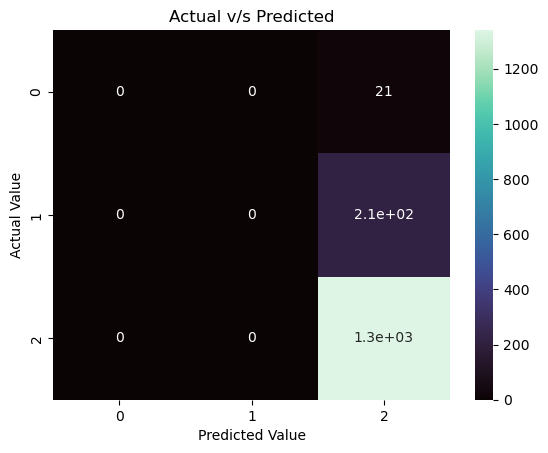

In [115]:
plt.title('Actual v/s Predicted')
sns.heatmap(cm, annot = True, cmap = 'mako')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()

In [116]:
print(classification_report(y_test,y_pred))

                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        21
Serious Injury       0.00      0.00      0.00       214
 Slight Injury       0.85      1.00      0.92      1340

      accuracy                           0.85      1575
     macro avg       0.28      0.33      0.31      1575
  weighted avg       0.72      0.85      0.78      1575



### Step-5.2: NaiveBayes ML Model

In [117]:
from sklearn.naive_bayes import GaussianNB

model_nv = GaussianNB()

model_nv.fit(X_train,y_train)

GaussianNB()

In [118]:
y_pred = model_nv.predict(X_test)

In [119]:
nv_score = model_nv.score(X_test,y_test)
print('Naive Bayes Score: ',nv_score)

Naive Bayes Score:  0.8488888888888889


In [124]:
print('Accuracy Score: ',accuracy_score(y_test,y_pred))
print('Precision Score: ',precision_score(y_test,y_pred, average='weighted'))
print('Recall Score: ',recall_score(y_test,y_pred, average='weighted'))
print('F1 Score: ',f1_score(y_test,y_pred, average='weighted'))

Accuracy Score:  0.8488888888888889
Precision Score:  0.7631891804340785
Recall Score:  0.8488888888888889
F1 Score:  0.7836212234691075


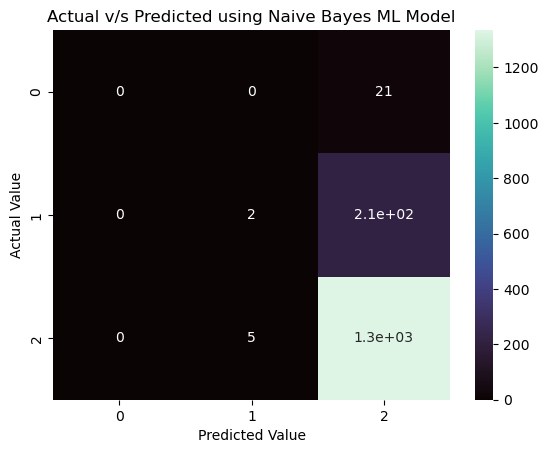

In [125]:
cm = confusion_matrix(y_test,y_pred)

plt.title('Actual v/s Predicted using Naive Bayes ML Model')
sns.heatmap(cm,annot = True, cmap = 'mako')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()

In [126]:
print(classification_report(y_test,y_pred))

                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        21
Serious Injury       0.29      0.01      0.02       214
 Slight Injury       0.85      1.00      0.92      1340

      accuracy                           0.85      1575
     macro avg       0.38      0.34      0.31      1575
  weighted avg       0.76      0.85      0.78      1575



### Step- 5.3: Vector VL Model

In [127]:
from sklearn.svm import SVC

model_svc = SVC()

model_svc.fit(X_train,y_train)

SVC()

In [128]:
y_pred = model_svc.predict(X_test)

In [150]:
print('Accuracy Score: ',accuracy_score(y_test,y_pred))
print('Precision Score: ',precision_score(y_test,y_pred, average='weighted'))
print('Recall Score: ',recall_score(y_test,y_pred, average='weighted'))
print('F1 Score: ',f1_score(y_test,y_pred, average='weighted'))

Accuracy Score:  0.8457142857142858
Precision Score:  0.7628569389648387
Recall Score:  0.8457142857142858
F1 Score:  0.7852857806019816


In [130]:
print(classification_report(y_test,y_pred))

                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        21
Serious Injury       0.00      0.00      0.00       214
 Slight Injury       0.85      1.00      0.92      1340

      accuracy                           0.85      1575
     macro avg       0.28      0.33      0.31      1575
  weighted avg       0.72      0.85      0.78      1575



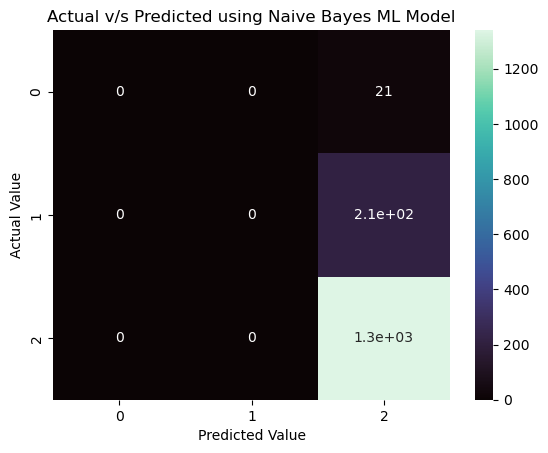

In [131]:
cm = confusion_matrix(y_test,y_pred)

plt.title('Actual v/s Predicted using Naive Bayes ML Model')
sns.heatmap(cm,annot = True, cmap = 'mako')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()

In [132]:
svm_score = accuracy_score(y_test,y_pred)

In [133]:
lr_score,nv_score,svm_score

(0.8507936507936508, 0.8488888888888889, 0.8507936507936508)

In [134]:
model_svc.score(X_test,y_test)

0.8507936507936508

# Step- 5.4: Decision Tree ML Model 

In [135]:
from sklearn.tree import DecisionTreeClassifier

In [136]:
model_dt = DecisionTreeClassifier()

model_dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [137]:
y_pred = model_dt.predict(X_test)

In [151]:
print('Accuracy Score: ',accuracy_score(y_test,y_pred))
print('Precision Score: ',precision_score(y_test,y_pred, average='weighted'))
print('Recall Score: ',recall_score(y_test,y_pred, average='weighted'))
print('F1 Score: ',f1_score(y_test,y_pred, average='weighted'))

Accuracy Score:  0.8457142857142858
Precision Score:  0.7628569389648387
Recall Score:  0.8457142857142858
F1 Score:  0.7852857806019816


In [152]:
dt_score = accuracy_score(y_test,y_pred)
dt_score

0.8457142857142858

In [153]:
from sklearn.tree import plot_tree

### Step- 5.5: KNN Model

In [154]:
from sklearn.neighbors import KNeighborsClassifier

In [155]:
model_knn = KNeighborsClassifier(n_neighbors = 14) # k = 14

model_knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=14)

In [156]:
y_pred = model_knn.predict(X_test)

In [157]:
print(classification_report(y_test,y_pred))

                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        21
Serious Injury       0.28      0.02      0.04       214
 Slight Injury       0.85      0.99      0.92      1340

      accuracy                           0.85      1575
     macro avg       0.38      0.34      0.32      1575
  weighted avg       0.76      0.85      0.79      1575



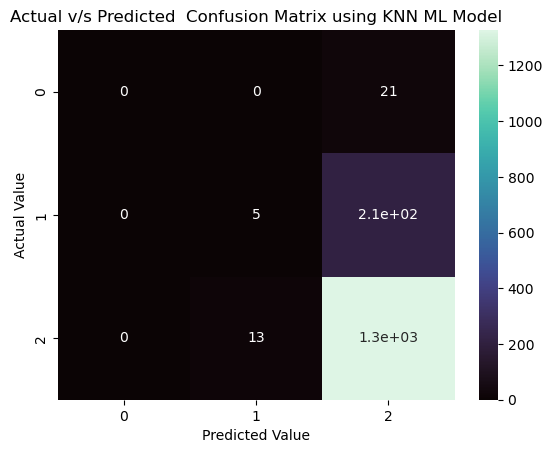

In [158]:
cm = confusion_matrix(y_test,y_pred)

plt.title('Actual v/s Predicted  Confusion Matrix using KNN ML Model')
sns.heatmap(cm,annot = True, cmap = 'mako')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()

In [159]:
knn_score = accuracy_score(y_test,y_pred)

In [181]:
all_model_score = [lr_score,nv_score,svm_score,dt_score,knn_score,rf_score]
model_name = ['Logistic','Naive','SVM','Decision Tree','KNN','Random Forest']
# print(len(all_model_score))
print('Done')

Done


In [182]:
from sklearn.ensemble import RandomForestClassifier


model_rf = RandomForestClassifier(n_estimators = 200) # Parameter change from default(100) to 200

model_rf.fit(X_train,y_train)  # Learning part 

RandomForestClassifier(n_estimators=200)

In [183]:
y_pred = model_rf.predict(X_test)

In [184]:
print('Accuracy Score: ',accuracy_score(y_test,y_pred))
print('Precision Score: ',precision_score(y_test,y_pred, average='weighted'))
print('Recall Score: ',recall_score(y_test,y_pred, average='weighted'))
print('F1 Score: ',f1_score(y_test,y_pred, average='weighted'))

Accuracy Score:  0.8501587301587301
Precision Score:  0.7694397996688073
Recall Score:  0.8501587301587301
F1 Score:  0.783094253416834


In [185]:
rf_score = accuracy_score(y_test,y_pred)
rf_score

0.8501587301587301

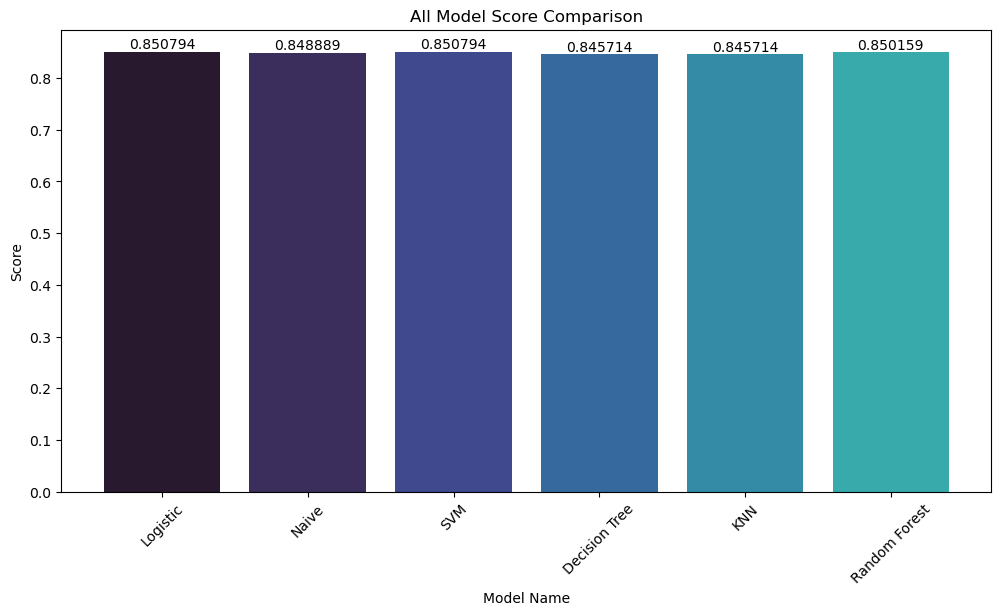

In [186]:
plt.figure(figsize=(12,6))
plt.title('All Model Score Comparison')
ax = plt.bar(x = model_name, height= all_model_score,color = sns.color_palette('mako',8))
plt.bar_label(ax)
plt.xlabel('Model Name')
plt.ylabel('Score')
plt.xticks(rotation = 45)
plt.savefig("model_scores.jpg", dpi=300, bbox_inches='tight')
plt.show()

# Step-7: Best Model Save 

In [188]:
import pickle
with open('road_accident_severity_pred.pkl','wb') as f:
    pickle.dump(model_lr,f)
print('Done')

Done


In [163]:
os.getcwd()

'C:\\Users\\Aaryan Bhardwaj\\Minor Project'